# 03 — Text-only Classical Baselines

Text-only baselines for the two tasks (topic and priority) using **TF-IDF + Logistic Regression** and **TF-IDF + Linear SVM**, with ngram range (1, 2). We compare the three input fields (`text_subject`, `text_body`, `text_subject_body`) and report both a stratified and a grouped-by-subject split. No metadata, regex, or transformers yet.

## 1 — Imports and configuration

A single cell pinning paths, label orderings, the random seed, and the TF-IDF defaults that the spec mandates.

In [ ]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GroupShuffleSplit,
)
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    f1_score,
)

warnings.filterwarnings("ignore", category=UserWarning)

DATA_PATH = Path("../data/processed/frozen_dataset.csv")
RANDOM_STATE = 42
TEST_SIZE = 0.2

TOPIC_ORDER = ["administrative", "course-exam", "event", "deadline-action", "advertisement"]
PRIORITY_ORDER = ["High", "Medium", "Low"]
TEXT_FIELDS = ["text_subject", "text_body", "text_subject_body"]

TFIDF_KWARGS = dict(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    lowercase=False,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_colwidth", 80)

print("Data:", DATA_PATH.resolve())

Data: D:\UniGe\3\NLP\NLP-project\Preprocessing\frozen_dataset.csv


## 2 — Load the frozen dataset

We load the artifact produced by `Preprocessing/Preprocessing_pipeline.ipynb` and fill empty text cells with empty strings (TfidfVectorizer doesn't accept NaN).

In [ ]:
df = pd.read_csv(DATA_PATH)
for col in TEXT_FIELDS:
    df[col] = df[col].fillna("").astype(str)

print(f"Shape   : {df.shape}")
print(f"Columns : {list(df.columns)}")
print()
print("Topic counts:")
print(df["topic"].value_counts().reindex(TOPIC_ORDER).to_string())
print()
print("Priority counts:")
print(df["priority"].value_counts().reindex(PRIORITY_ORDER).to_string())

Shape   : (919, 8)
Columns : ['id', 'subject', 'body_plain', 'topic', 'priority', 'text_subject', 'text_body', 'text_subject_body']

Topic counts:
topic
administrative     159
course-exam        267
event              189
deadline-action    197
advertisement      107

Priority counts:
priority
High      272
Medium    309
Low       338


## 3 — Stratified train/test split (per task)

We split row indices once per task so that all input fields share the same train/test partition for that task. This makes the field comparison fair (`text_subject` vs `text_body` vs `text_subject_body` are evaluated on the same held-out rows).

- `test_size = 0.2`
- `random_state = 42`
- `stratify` on the task label

In [ ]:
indices = np.arange(len(df))

idx_train_topic, idx_test_topic = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df["topic"].values,
)

idx_train_priority, idx_test_priority = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df["priority"].values,
)

SPLITS = {
    "topic": (idx_train_topic, idx_test_topic),
    "priority": (idx_train_priority, idx_test_priority),
}

for task, (tr, te) in SPLITS.items():
    print(f"{task:<8} -> train={len(tr):>4}  test={len(te):>4}")

topic    -> train= 735  test= 184
priority -> train= 735  test= 184


## 4 — Helpers: pipelines, CV, evaluation, results recorder

Three small utilities keep the experiment loop short and readable:

- `build_pipeline(model_name)` — returns a `Pipeline(TfidfVectorizer → classifier)` with the required defaults.
- `cv_macro_f1(pipeline, X, y)` — stratified 5-fold CV, returns mean and std of macro-F1.
- `evaluate_on_test(pipeline, X_train, y_train, X_test, y_test, label_order)` — fits on train, scores on test, returns a metrics dict and the predictions.
- `record(...)` — appends a row to a list of dicts that becomes the master results table.

In [ ]:
MODEL_NAMES = {
    "logreg": "TF-IDF + Logistic Regression",
    "linsvc": "TF-IDF + Linear SVM",
}


def build_classifier(model_name: str):
    if model_name == "logreg":
        return LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="lbfgs",
        )
    if model_name == "linsvc":
        return LinearSVC(class_weight="balanced", max_iter=5000)
    raise ValueError(f"Unknown model: {model_name}")


def build_pipeline(model_name: str) -> Pipeline:
    return Pipeline(
        steps=[
            ("tfidf", TfidfVectorizer(**TFIDF_KWARGS)),
            ("clf", build_classifier(model_name)),
        ]
    )


def cv_macro_f1(pipeline: Pipeline, X, y, n_splits: int = 5):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring="f1_macro", n_jobs=-1)
    return float(scores.mean()), float(scores.std())


def evaluate_on_test(pipeline: Pipeline, X_train, y_train, X_test, y_test, labels):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_precision": p_macro,
        "macro_recall": r_macro,
        "macro_f1": f_macro,
        "weighted_f1": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    }
    return pipeline, y_pred, metrics


RESULTS: list[dict] = []


def record(task, split_type, input_field, model, metrics, cv_mean=None, cv_std=None):
    row = {
        "task": task,
        "split_type": split_type,
        "input_field": input_field,
        "model": model,
        "cv_macro_f1_mean": cv_mean,
        "cv_macro_f1_std": cv_std,
        **{k: round(v, 4) for k, v in metrics.items()},
    }
    RESULTS.append(row)
    return row


print("Helpers ready.")

Helpers ready.


## 5 — Baseline 0: Majority class (optional, beyond report scope)

A floor baseline that always predicts the most common training-fold class.

In [ ]:
TASK_LABELS = {"topic": TOPIC_ORDER, "priority": PRIORITY_ORDER}


def majority_baseline(task: str):
    idx_train, idx_test = SPLITS[task]
    y_train = df.loc[idx_train, task].values
    y_test = df.loc[idx_test, task].values
    majority = pd.Series(y_train).value_counts().idxmax()
    y_pred = np.full_like(y_test, fill_value=majority)
    p, r, f, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_precision": p,
        "macro_recall": r,
        "macro_f1": f,
        "weighted_f1": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    }
    record(task, "stratified", "—", f"Majority ({majority})", metrics)
    print(f"[majority] {task:<8} -> predicts '{majority}' | "
          f"acc={metrics['accuracy']:.3f}  macroF1={metrics['macro_f1']:.3f}")
    return majority, y_pred, metrics


for task in ("topic", "priority"):
    majority_baseline(task)

[majority] topic    -> predicts 'course-exam' | acc=0.293  macroF1=0.091
[majority] priority -> predicts 'Low' | acc=0.370  macroF1=0.180


## 6 — Baseline 1 & 2: TF-IDF + classifier

We loop over `(task, model, input_field)` and for each combination:

1. Run **5-fold stratified CV** on the training set (mean and std of macro-F1).
2. Fit on the full training set and **score once on the held-out test set**.
3. Save predictions and the trained pipeline so we can build plots and the error analysis later.

Both Logistic Regression and Linear SVM are evaluated on **all three** input fields and on **both** tasks (the spec only requires `text_subject_body` for SVM, but running everything is cheap on this corpus and makes the comparison cleaner).

In [ ]:
FITTED: dict = {}
PREDICTIONS: dict = {}


def run_text_baseline(task: str, model_name: str, field: str):
    idx_train, idx_test = SPLITS[task]
    X_train = df.loc[idx_train, field].values
    X_test = df.loc[idx_test, field].values
    y_train = df.loc[idx_train, task].values
    y_test = df.loc[idx_test, task].values
    labels = TASK_LABELS[task]

    cv_mean, cv_std = cv_macro_f1(build_pipeline(model_name), X_train, y_train)
    pipe, y_pred, metrics = evaluate_on_test(
        build_pipeline(model_name), X_train, y_train, X_test, y_test, labels
    )

    key = (task, model_name, field, "stratified")
    FITTED[key] = pipe
    PREDICTIONS[key] = (y_test, y_pred)

    record(task, "stratified", field, MODEL_NAMES[model_name], metrics, cv_mean, cv_std)
    print(f"[{model_name:<6}] {task:<8} | {field:<18} | "
          f"CV macroF1={cv_mean:.3f}±{cv_std:.3f} | "
          f"test acc={metrics['accuracy']:.3f} macroF1={metrics['macro_f1']:.3f}")


for task in ("topic", "priority"):
    print(f"\n=== Task: {task} ===")
    for model_name in ("logreg", "linsvc"):
        for field in TEXT_FIELDS:
            run_text_baseline(task, model_name, field)


=== Task: topic ===


[logreg] topic    | text_subject       | CV macroF1=0.739±0.035 | test acc=0.783 macroF1=0.774


[logreg] topic    | text_body          | CV macroF1=0.800±0.027 | test acc=0.821 macroF1=0.812


[logreg] topic    | text_subject_body  | CV macroF1=0.820±0.022 | test acc=0.832 macroF1=0.824


[linsvc] topic    | text_subject       | CV macroF1=0.760±0.030 | test acc=0.815 macroF1=0.799


...

[linsvc] topic    | text_subject_body  | CV macroF1=0.844±0.035 | test acc=0.870 macroF1=0.861

=== Task: priority ===
[logreg] priority | text_subject       | CV macroF1=0.704±0.017 | test acc=0.712 macroF1=0.702


[logreg] priority | text_body          | CV macroF1=0.722±0.022 | test acc=0.734 macroF1=0.729


[logreg] priority | text_subject_body  | CV macroF1=0.726±0.032 | test acc=0.734 macroF1=0.729
[linsvc] priority | text_subject       | CV macroF1=0.703±0.020 | test acc=0.734 macroF1=0.726


[linsvc] priority | text_body          | CV macroF1=0.737±0.033 | test acc=0.766 macroF1=0.765


[linsvc] priority | text_subject_body  | CV macroF1=0.739±0.036 | test acc=0.761 macroF1=0.759


## 7 — Stratified results table

The full results table for the stratified split, sorted by macro-F1 within each task. The "best stratified model" per task is the one we'll re-evaluate under the group-aware split next, and use for the confusion matrix and error analysis.

In [ ]:
results_df = pd.DataFrame(RESULTS)

display_cols = [
    "task", "split_type", "input_field", "model",
    "cv_macro_f1_mean", "cv_macro_f1_std",
    "accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_f1",
]
results_df[display_cols].sort_values(["task", "macro_f1"], ascending=[True, False])

,task,split_type,input_field,model,cv_macro_f1_mean,cv_macro_f1_std,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
12,priority,stratified,text_body,TF-IDF + Linear SVM,0.737123,0.033298,0.7663,0.7650,0.7665,0.7652,0.7670
13,priority,stratified,text_subject_body,TF-IDF + Linear SVM,0.738581,0.035704,0.7609,0.7579,0.7599,0.7586,0.7609
10,priority,stratified,text_subject_body,TF-IDF + Logistic Regression,0.726088,0.031545,0.7337,0.7294,0.7327,0.7294,0.7333
9,priority,stratified,text_body,TF-IDF + Logistic Regression,0.722472,0.021514,0.7337,0.7285,0.7335,0.7287,0.7320
11,priority,stratified,text_subject,TF-IDF + Linear SVM,0.702702,0.019676,0.7337,0.7267,0.7333,0.7259,0.7267
8,priority,stratified,text_subject,TF-IDF + Logistic Regression,0.704489,0.016790,0.7120,0.7028,0.7136,0.7023,0.7031
1,priority,stratified,—,Majority (Low),NaN,NaN,0.3696,0.1232,0.3333,0.1799,0.1994
7,topic,stratified,text_subject_body,TF-IDF + Linear SVM,0.843629,0.035207,0.8696,0.8847,0.8478,0.8610,0.8681
6,topic,stratified,text_body,TF-IDF + Linear SVM,0.823947,0.038586,0.8587,0.8665,0.8346,0.8456,0.8565
4,topic,stratified,text_subject_body,TF-IDF + Logistic Regression,0.819734,0.021956,0.8315,0.8650,0.8035,0.8241,0.8295


In [ ]:
def best_stratified_model(task: str):
    sub = results_df[(results_df["task"] == task)
                     & (results_df["split_type"] == "stratified")
                     & (results_df["input_field"] != "—")]
    return sub.sort_values("macro_f1", ascending=False).iloc[0]


BEST = {task: best_stratified_model(task) for task in ("topic", "priority")}
for task, row in BEST.items():
    print(f"Best stratified — {task:<8}: {row['model']} on {row['input_field']} "
          f"| macroF1={row['macro_f1']:.3f}  acc={row['accuracy']:.3f}")

Best stratified — topic   : TF-IDF + Linear SVM on text_subject_body | macroF1=0.861  acc=0.870
Best stratified — priority: TF-IDF + Linear SVM on text_body | macroF1=0.765  acc=0.766


## 8 — Grouped-by-subject split (`GroupShuffleSplit` by `text_subject`)

About 22% of rows share a repeated subject, so a random split inflates scores. We re-evaluate the best stratified model per task under a subject-grouped split (rows with the same `text_subject` stay on one side). The drop versus the stratified score is the part that came from template memorization.

In [ ]:
def grouped_split_indices(groups, test_size=TEST_SIZE, seed=RANDOM_STATE):
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    return next(gss.split(np.arange(len(groups)), groups=groups))


groups_subject = df["text_subject"].values
idx_train_g, idx_test_g = grouped_split_indices(groups_subject)

print(f"Grouped split  -> train={len(idx_train_g)}  test={len(idx_test_g)}")
print(f"Subject overlap between train and test: "
      f"{len(set(df.loc[idx_train_g, 'text_subject']) & set(df.loc[idx_test_g, 'text_subject']))} "
      f"(should be 0)")

GROUPED = {}
for task in ("topic", "priority"):
    best_row = BEST[task]
    model_name = "logreg" if "Logistic" in best_row["model"] else "linsvc"
    field = "text_subject_body"

    X_train = df.loc[idx_train_g, field].values
    X_test = df.loc[idx_test_g, field].values
    y_train = df.loc[idx_train_g, task].values
    y_test = df.loc[idx_test_g, task].values

    pipe = build_pipeline(model_name)
    pipe, y_pred, metrics = evaluate_on_test(
        pipe, X_train, y_train, X_test, y_test, TASK_LABELS[task]
    )
    GROUPED[task] = {"pipeline": pipe, "y_test": y_test, "y_pred": y_pred,
                     "metrics": metrics, "model_name": model_name}
    record(task, "grouped_subject", field, MODEL_NAMES[model_name], metrics)
    print(f"[grouped] {task:<8} | {MODEL_NAMES[model_name]} | "
          f"acc={metrics['accuracy']:.3f} macroF1={metrics['macro_f1']:.3f} "
          f"weightedF1={metrics['weighted_f1']:.3f}")

Grouped split  -> train=727  test=192
Subject overlap between train and test: 0 (should be 0)


[grouped] topic    | TF-IDF + Linear SVM | acc=0.802 macroF1=0.804 weightedF1=0.805


[grouped] priority | TF-IDF + Linear SVM | acc=0.703 macroF1=0.705 weightedF1=0.704


## 9 — Master results table

All experiments in one place: majority baseline, both classifiers across all input fields, and the grouped-by-subject re-evaluation of the best models.

In [ ]:
results_df = pd.DataFrame(RESULTS)
results_df_display = results_df[display_cols].copy()
results_df_display = results_df_display.sort_values(
    ["task", "split_type", "macro_f1"], ascending=[True, True, False]
).reset_index(drop=True)
results_df_display

,task,split_type,input_field,model,cv_macro_f1_mean,cv_macro_f1_std,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,priority,grouped_subject,text_subject_body,TF-IDF + Linear SVM,NaN,NaN,0.7031,0.7081,0.7035,0.7051,0.7045
1,priority,stratified,text_body,TF-IDF + Linear SVM,0.737123,0.033298,0.7663,0.7650,0.7665,0.7652,0.7670
2,priority,stratified,text_subject_body,TF-IDF + Linear SVM,0.738581,0.035704,0.7609,0.7579,0.7599,0.7586,0.7609
3,priority,stratified,text_subject_body,TF-IDF + Logistic Regression,0.726088,0.031545,0.7337,0.7294,0.7327,0.7294,0.7333
4,priority,stratified,text_body,TF-IDF + Logistic Regression,0.722472,0.021514,0.7337,0.7285,0.7335,0.7287,0.7320
5,priority,stratified,text_subject,TF-IDF + Linear SVM,0.702702,0.019676,0.7337,0.7267,0.7333,0.7259,0.7267
6,priority,stratified,text_subject,TF-IDF + Logistic Regression,0.704489,0.016790,0.7120,0.7028,0.7136,0.7023,0.7031
7,priority,stratified,—,Majority (Low),NaN,NaN,0.3696,0.1232,0.3333,0.1799,0.1994
8,topic,grouped_subject,text_subject_body,TF-IDF + Linear SVM,NaN,NaN,0.8021,0.8306,0.8059,0.8041,0.8045
9,topic,stratified,text_subject_body,TF-IDF + Linear SVM,0.843629,0.035207,0.8696,0.8847,0.8478,0.8610,0.8681


# Appendix
The remaining sections (plots, per-class reports, and error analysis of the baseline models) go beyond what the report covers for this baseline notebook; the report's error analysis is on the final models.

## 10 — Plots

Macro-F1 bar charts, confusion matrices for the best models, and a stratified vs grouped comparison.

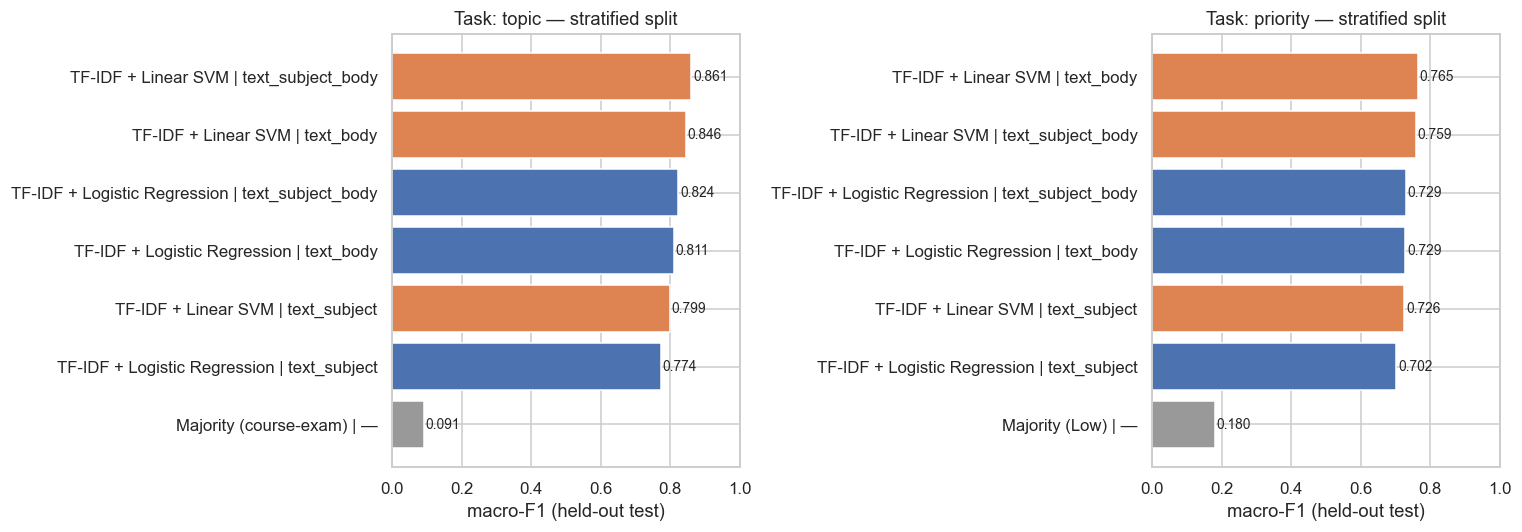

In [ ]:
def plot_macro_f1(task: str, ax):
    sub = results_df[(results_df["task"] == task)
                     & (results_df["split_type"] == "stratified")]
    sub = sub.sort_values("macro_f1", ascending=True)
    labels = sub["model"] + " | " + sub["input_field"]
    colors = ["#4C72B0" if "Logistic" in m else
              "#DD8452" if "SVM" in m else "#999999" for m in sub["model"]]
    ax.barh(labels, sub["macro_f1"], color=colors)
    ax.set_xlim(0, 1.0)
    ax.set_xlabel("macro-F1 (held-out test)")
    ax.set_title(f"Task: {task} — stratified split")
    for y, v in enumerate(sub["macro_f1"]):
        ax.text(v + 0.005, y, f"{v:.3f}", va="center", fontsize=9)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_macro_f1("topic", axes[0])
plot_macro_f1("priority", axes[1])
plt.tight_layout()
plt.show()

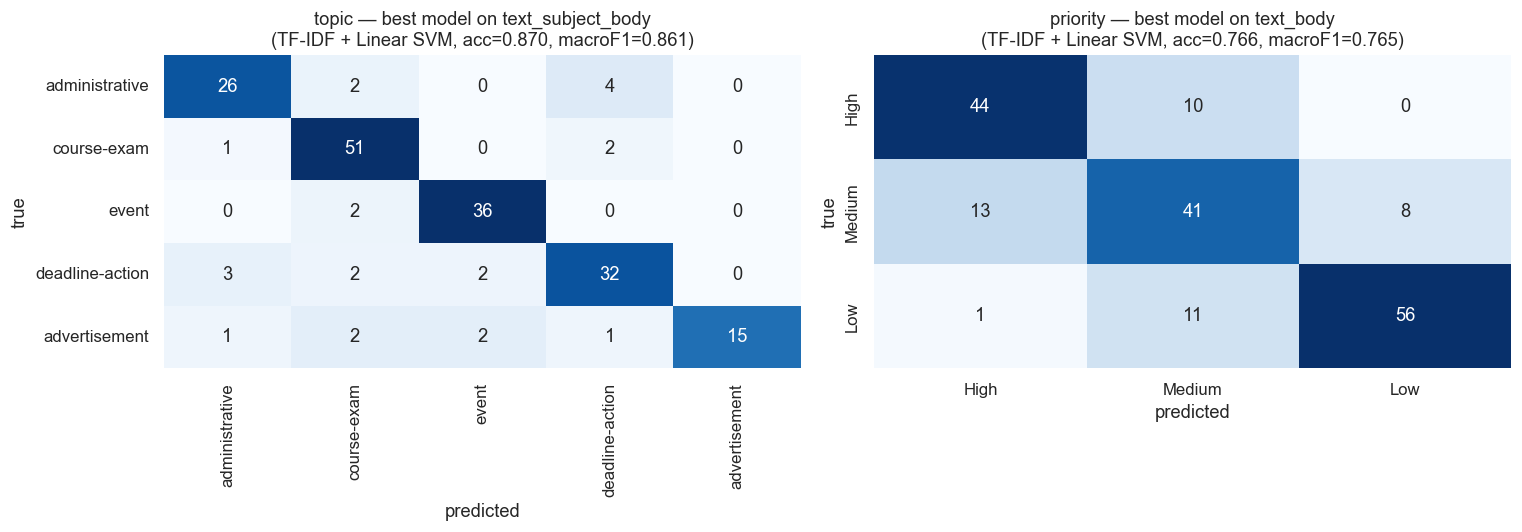

In [ ]:
def confusion_for_best(task: str, ax):
    row = BEST[task]
    model_name = "logreg" if "Logistic" in row["model"] else "linsvc"
    field = row["input_field"]
    key = (task, model_name, field, "stratified")
    y_test, y_pred = PREDICTIONS[key]
    labels = TASK_LABELS[task]

    cm = confusion_matrix(y_test, y_pred, labels=labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels, ax=ax, cbar=False)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(f"{task} — best model on {field}\n({row['model']}, "
                 f"acc={row['accuracy']:.3f}, macroF1={row['macro_f1']:.3f})")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
confusion_for_best("topic", axes[0])
confusion_for_best("priority", axes[1])
plt.tight_layout()
plt.show()

topic    | stratified=0.861  grouped=0.804  drop=+0.057
priority | stratified=0.765  grouped=0.705  drop=+0.060


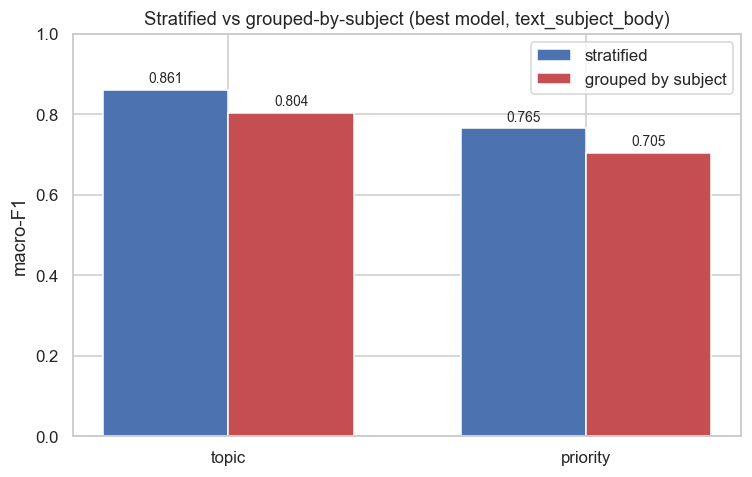

In [ ]:
def split_compare_data(task: str):
    best = BEST[task]
    strat = best["macro_f1"]
    grouped = GROUPED[task]["metrics"]["macro_f1"]
    return strat, grouped


tasks = ["topic", "priority"]
strat_vals = [split_compare_data(t)[0] for t in tasks]
group_vals = [split_compare_data(t)[1] for t in tasks]

x = np.arange(len(tasks))
w = 0.35

fig, ax = plt.subplots(figsize=(7, 4.5))
b1 = ax.bar(x - w / 2, strat_vals, w, label="stratified", color="#4C72B0")
b2 = ax.bar(x + w / 2, group_vals, w, label="grouped by subject", color="#C44E52")
ax.set_xticks(x)
ax.set_xticklabels(tasks)
ax.set_ylim(0, 1.0)
ax.set_ylabel("macro-F1")
ax.set_title("Stratified vs grouped-by-subject (best model, text_subject_body)")
ax.legend()
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f"{h:.3f}",
            ha="center", va="bottom", fontsize=9)

for t, s, g in zip(tasks, strat_vals, group_vals):
    drop = s - g
    print(f"{t:<8} | stratified={s:.3f}  grouped={g:.3f}  drop={drop:+.3f}")

plt.tight_layout()
plt.show()

## 11 — Per-class report (best models)

The `classification_report` for each best stratified model — useful to read alongside the confusion matrix.

In [ ]:
for task in ("topic", "priority"):
    row = BEST[task]
    model_name = "logreg" if "Logistic" in row["model"] else "linsvc"
    field = row["input_field"]
    y_test, y_pred = PREDICTIONS[(task, model_name, field, "stratified")]
    print(f"=== {task.upper()} | {row['model']} | {field} ===")
    print(classification_report(y_test, y_pred, labels=TASK_LABELS[task], zero_division=0))
    print()

=== TOPIC | TF-IDF + Linear SVM | text_subject_body ===
                 precision    recall  f1-score   support

 administrative       0.84      0.81      0.83        32
    course-exam       0.86      0.94      0.90        54
          event       0.90      0.95      0.92        38
deadline-action       0.82      0.82      0.82        39
  advertisement       1.00      0.71      0.83        21

       accuracy                           0.87       184
      macro avg       0.88      0.85      0.86       184
   weighted avg       0.87      0.87      0.87       184


=== PRIORITY | TF-IDF + Linear SVM | text_body ===
              precision    recall  f1-score   support

        High       0.76      0.81      0.79        54
      Medium       0.66      0.66      0.66        62
         Low       0.88      0.82      0.85        68

    accuracy                           0.77       184
   macro avg       0.76      0.77      0.77       184
weighted avg       0.77      0.77      0.77       

## 12 — Error analysis: topic

We pull misclassified examples from the best stratified topic model. We also tally the most common confusion types (e.g. `administrative -> deadline-action`) so we can see which class boundaries are weakest.

In [ ]:
def errors_for_task(task: str, n_show: int = 18):
    row = BEST[task]
    model_name = "logreg" if "Logistic" in row["model"] else "linsvc"
    field = row["input_field"]
    idx_train, idx_test = SPLITS[task]
    y_test, y_pred = PREDICTIONS[(task, model_name, field, "stratified")]

    err_mask = y_test != y_pred
    err_test_idx = np.array(idx_test)[err_mask]
    out = pd.DataFrame({
        "id": df.loc[err_test_idx, "id"].values,
        "text_subject": df.loc[err_test_idx, "text_subject"].values,
        f"true_{task}": y_test[err_mask],
        f"pred_{task}": y_pred[err_mask],
        "topic" if task == "priority" else "priority":
            df.loc[err_test_idx, "topic" if task == "priority" else "priority"].values,
        "snippet": df.loc[err_test_idx, "text_body"].str.slice(0, 120).values,
    })
    return out, err_mask


topic_errors, _ = errors_for_task("topic")
print(f"Topic errors: {len(topic_errors)} / {len(SPLITS['topic'][1])} test rows "
      f"({len(topic_errors) / len(SPLITS['topic'][1]) * 100:.1f}%)\n")

print("Most common confusion types (true -> pred):")
conf_types = (topic_errors[["true_topic", "pred_topic"]]
              .apply(lambda r: f"{r['true_topic']} -> {r['pred_topic']}", axis=1)
              .value_counts())
print(conf_types.to_string())
print()
topic_errors.head(18)

Topic errors: 24 / 184 test rows (13.0%)

Most common confusion types (true -> pred):
administrative -> deadline-action    4
deadline-action -> administrative    3
deadline-action -> course-exam       2
administrative -> course-exam        2
advertisement -> course-exam         2
event -> course-exam                 2
deadline-action -> event             2
advertisement -> event               2
course-exam -> deadline-action       2
course-exam -> administrative        1
advertisement -> administrative      1
advertisement -> deadline-action     1



,id,text_subject,true_topic,pred_topic,priority,snippet
0,70532d9c871cdd62,aulaweb2024 90539: june oral exam: possible change of date,deadline-action,course-exam,High,90539 -> forum -> annunci -> june oral exam: possible change of date url jun...
1,fea7c6c1826067d9,aulaweb2025 info-11964: university of genoa services for students with disab...,administrative,course-exam,Medium,info-11964 -> forum -> news -> university of genoa services for students wit...
2,a36b77d5dcf48d8a,aulaweb2024 info-10852: computer science master socials,advertisement,course-exam,Low,info-10852 -> forum -> announcements -> computer science master socials url ...
3,711540235eca91d2,aulaweb2025 90541: exist 2026: multimodal sexism identification with sensor ...,advertisement,course-exam,Low,90541 -> forum -> news -> exist 2026: multimodal sexism identification with ...
4,f461697b6ab18f8c,aulaweb2024 info-10852: computer science workshop 2025,event,course-exam,Medium,info-10852 -> forum -> announcements -> computer science workshop 2025 url c...
5,168bdbfd1f97a52d,[studenti] prima edizione della serata writing for toilet al kowalski 15 apr...,deadline-action,event,Medium,cosa può fare una web radio universitaria quando lavora a stretto contatto c...
6,be2ade6d76882e5f,aulaweb2025 info-11964: weather alert tomorrow - september 22nd,administrative,course-exam,High,info-11964 -> forum -> news -> weather alert tomorrow - september 22nd url w...
7,849a23cb5246e405,[studenti] abilità atletiche - il podcast di unige radio,advertisement,event,Low,"il comitato per le pari opportunità, nella giornata internazionale delle per..."
8,99170f1ad8caeeae,"aulaweb2025 info-11964: ""binary analysis and secure coding"" starts on 23rd",course-exam,administrative,High,"info-11964 -> forum -> news -> ""binary analysis and secure coding"" starts on..."
9,19a47b8d1caf0a13,aulaweb2025 90537: thesis in erasmus,administrative,deadline-action,Low,90537 -> forum -> news -> thesis in erasmus url thesis in erasmus di gianna ...


## 13 — Error analysis: priority

Same idea for the priority model. We also look specifically at the three "ordinal-adjacent" confusion buckets — `High↔Medium`, `Medium↔Low`, `High↔Low` — because Medium is the most semantically ambiguous priority class.

In [ ]:
priority_errors, _ = errors_for_task("priority")
print(f"Priority errors: {len(priority_errors)} / {len(SPLITS['priority'][1])} test rows "
      f"({len(priority_errors) / len(SPLITS['priority'][1]) * 100:.1f}%)\n")

print("Most common confusion types (true -> pred):")
conf_types_p = (priority_errors[["true_priority", "pred_priority"]]
                .apply(lambda r: f"{r['true_priority']} -> {r['pred_priority']}", axis=1)
                .value_counts())
print(conf_types_p.to_string())
print()
print("Adjacency buckets:")
def bucket(t, p):
    pair = frozenset([t, p])
    if pair == frozenset(["High", "Medium"]): return "High <-> Medium"
    if pair == frozenset(["Medium", "Low"]):  return "Medium <-> Low"
    if pair == frozenset(["High", "Low"]):    return "High <-> Low"
    return "same"


buckets = priority_errors.apply(lambda r: bucket(r["true_priority"], r["pred_priority"]), axis=1)
print(buckets.value_counts().to_string())
print()
priority_errors.head(18)

Priority errors: 43 / 184 test rows (23.4%)

Most common confusion types (true -> pred):
Medium -> High    13
Low -> Medium     11
High -> Medium    10
Medium -> Low      8
Low -> High        1

Adjacency buckets:
High <-> Medium    23
Medium <-> Low     19
High <-> Low        1



,id,text_subject,true_priority,pred_priority,topic,snippet
0,3c32517d08c4d18d,[studenti] elezioni studentesche - b.a. 2025/2027 (affluenza parziale ore 8....,Low,Medium,administrative,area legale e generale - servizio affari giuridici e istituzionali settore a...
1,18df6ee5b34e1614,re: auk activity: drl,Medium,High,course-exam,usually i'm staying in the lab from 9 to 17. so come when you want. in the 8...
2,76ce6c667d4db172,aulaweb2025 90529: references updated,Low,High,course-exam,90529 -> forum -> news and relevant information -> references updated url re...
3,b720664514399656,aulaweb2024 101809: ri: competitive programming,Medium,High,course-exam,101809 -> forum -> news forum -> competitive programming url ri: competitive...
4,f026b494e258acfc,aulaweb2024 80412: exam 16/7,High,Medium,deadline-action,80412 -> forum -> technical discussions (students can write here) -> exam 16...
5,437e2779872d9435,aulaweb2025 info-11964: a reading suggestion,Low,Medium,course-exam,info-11964 -> forum -> news -> a reading suggestion url a reading suggestion...
6,405190b35f428248,re: about the auk,Medium,High,course-exam,dear all you should have all received an email to put you in touch with the ...
7,10ac71fa8465c7bc,[studenti] bando servizio civile universale - presentazione domande entro il...,High,Medium,deadline-action,"gentili, fino all’8 aprile 2026 alle 14,00 è possibile iscriversi al nuovo b..."
8,e7f75472473f9188,[studenti] questionario su economia circolare e qualità degli spazi pubblici,Low,Medium,deadline-action,invio in qualità di delegata del rettore alla smart city pregandovi di rispo...
9,b86fe7b26b064a7e,[studenti] save the date - incontra il clab team - lunedì 13 ottobre h 17.00,Low,Medium,event,*e' aperta la seconda edizione del contamination lab dell'università di geno...


## 14 — Discussion

The questions the spec asked us to answer, in order. Numbers below are rendered live from `results_df` so the discussion stays in sync with what was actually run.

In [ ]:
def field_winner(task: str):
    sub = results_df[(results_df["task"] == task)
                     & (results_df["split_type"] == "stratified")
                     & (results_df["input_field"] != "—")]
    return (sub.groupby("input_field")["macro_f1"].mean().sort_values(ascending=False))


def model_winner(task: str):
    sub = results_df[(results_df["task"] == task)
                     & (results_df["split_type"] == "stratified")
                     & (results_df["input_field"] != "—")]
    return sub.groupby("model")["macro_f1"].mean().sort_values(ascending=False)


for task in ("topic", "priority"):
    print(f"--- {task.upper()} ---")
    print("Field ranking (avg macro-F1 over both classifiers):")
    print(field_winner(task).round(3).to_string())
    print("\nModel ranking (avg macro-F1 over all input fields):")
    print(model_winner(task).round(3).to_string())
    s, g = split_compare_data(task)
    print(f"\nBest macro-F1 stratified : {s:.3f}")
    print(f"macro-F1 grouped-by-subj.: {g:.3f}")
    print(f"Drop                     : {s - g:+.3f}\n")

--- TOPIC ---
Field ranking (avg macro-F1 over both classifiers):
input_field
text_subject_body    0.843
text_body            0.829
text_subject         0.786

Model ranking (avg macro-F1 over all input fields):
model
TF-IDF + Linear SVM             0.835
TF-IDF + Logistic Regression    0.803

Best macro-F1 stratified : 0.861
macro-F1 grouped-by-subj.: 0.804
Drop                     : +0.057

--- PRIORITY ---
Field ranking (avg macro-F1 over both classifiers):
input_field
text_body            0.747
text_subject_body    0.744
text_subject         0.714

Model ranking (avg macro-F1 over all input fields):
model
TF-IDF + Linear SVM             0.75
TF-IDF + Logistic Regression    0.72

Best macro-F1 stratified : 0.765
macro-F1 grouped-by-subj.: 0.705
Drop                     : +0.060



### Interpretation

Linear SVM and Logistic Regression are close, with `text_subject_body` generally the strongest input. Topic scores higher than priority because its classes have clearer vocabulary, while priority is more contextual (Medium is the hardest class). The grouped-by-subject split lowers the scores, showing that part of the stratified result came from repeated templates and that there is real headroom for the hybrid features added next.

## 15 — Final conclusion

In [ ]:
def summarize_best(task: str) -> str:
    row = BEST[task]
    s = row["macro_f1"]
    g = GROUPED[task]["metrics"]["macro_f1"]
    return (
        f"  - model     : {row['model']}\n"
        f"  - input     : {row['input_field']}\n"
        f"  - split     : stratified (also grouped-by-subject)\n"
        f"  - macro-F1  : {s:.3f}  (grouped-by-subject: {g:.3f})\n"
        f"  - accuracy  : {row['accuracy']:.3f}\n"
    )


print("Text-only baseline stage completed.\n")
print("Best topic model:")
print(summarize_best("topic"))
print("Best priority model:")
print(summarize_best("priority"))
print("Next step: use the best text-only model as the base and add hybrid feature families "
      "(length, language proxy, metadata, regex, lexicon).")

Text-only baseline stage completed.

Best topic model:
  - model     : TF-IDF + Linear SVM
  - input     : text_subject_body
  - split     : stratified (also grouped-by-subject)
  - macro-F1  : 0.861  (grouped-by-subject: 0.804)
  - accuracy  : 0.870

Best priority model:
  - model     : TF-IDF + Linear SVM
  - input     : text_body
  - split     : stratified (also grouped-by-subject)
  - macro-F1  : 0.765  (grouped-by-subject: 0.705)
  - accuracy  : 0.766

Next step:
Use the best text-only model as the base and incrementally add feature families:
  1. length-only and language-proxy baselines
  2. metadata features if recoverable
  3. regex / rule features
  4. lexical-semantic dictionary features
  5. NER-derived features
  6. full hybrid model
